# Introduction
Information Retrieval (IR) is a field of study dedicated to the organization and retrieval of information from vast and diverse collections of data. In the context of digital information, IR involves the development of techniques and systems that enable users to efficiently access relevant information. Key tasks in IR include indexing, searching, and ranking documents based on their relevance to user queries.

This assignment delves into various aspects of Information Retrieval, exploring fundamental concepts and practical applications. Throughout the assignment, we will examine techniques for document indexing, retrieval models, and the evaluation of IR systems using metrics such as precision, recall, and mean average precision. By delving into these topics, we aim to gain a comprehensive understanding of the core principles that govern effective information retrieval.

---
# Objective

In this assignment, it is time to put everything together to build your first search engine and then evaluate it. Specifically, you will complete the following tasks:

- Implementing various **probabilistic** retrieval models and then use them to answer queries.
- Evaluate the models implemented.

This assignment is based on a subset of the TREC 2003 Web Topic Distillation will be employed, featuring a curated subset of the WT10g (Web Track 10 gigabyte) corpus as the document collection. This chosen dataset will serve as the foundation for rigorously assessing the performance of the implemented Information Retrieval models. Utilizing a well-established benchmark such as TREC ensures a standardized and meaningful evaluation, allowing for robust comparisons between different models.


You can locate the necessary data in the following locations:

- **Data Folder:** 'government_data'
- **Documents Folder:** 'documents'
- **Topics (Queries) File:** 'gov.topics'
  - *Format:* Each line follows the pattern `<query_id> <query_text>`
- **Qrels (Query Relevance Judgements) File:** 'gov.qrels'
  - *Format:* Each line follows the pattern `<query_id> 0 <doc_id> <relevance>`
    - `<query_id>`: The unique identifier for the query.
    - `Q0`: A literal indicating the query and is usually constant.
    - `<doc_id>`: The identifier of the retrieved document.
    - `<rank>`: The rank assigned to the document by the retrieval system.
    - `<score>`: The retrieval score assigned to the document by the system.
    - `<run_id>`: A unique identifier for the run or retrieval system.  



# Preliminaries

Before proceeding to complete this assignment, it is crucial to update all functions in `utils.py` with the code created in the two assignments from last week: `1.1P - IR Indexing and Searching` and `1.2P - The Vector Space Model`.







In [1]:
import sys
print(sys.version)

3.11.15 | packaged by Anaconda, Inc. | (main, Mar 11 2026, 17:12:15) [MSC v.1942 64 bit (AMD64)]


In [2]:
import sys
!{sys.executable} -m pip install matplotlib


In [3]:
import sys
!{sys.executable} -m pip install nltk

In [4]:
import nltk
nltk.download('punkt')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\hasan\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\hasan\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [5]:
import nltk

nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\hasan\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\hasan\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [6]:
from collections import Counter
import math
import matplotlib.pyplot as plt
from utils import Preprocessor, Indexer, vsm_log_freq, vsm_jaccard, vsm_cosine, Retrieval


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\hasan\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


## Building the Document Index

In the next step, we will construct the document index for our collection by reading files from the `government_data/` folder.


In [7]:
indexer = Indexer(r'C:\Users\hasan\Downloads\2.1C-resources\2.1C - Probabilistic IR and Evaluation of Retrieval Models\government_data')
indexer.index()

Processing Files: 100%|████████████████████████████████████████████████████████████| 4082/4082 [01:05<00:00, 61.85it/s]


# Scoring IR models

Scoring Information Retrieval (IR) models play a pivotal role in ranking and retrieving relevant documents from a vast collection based on a user's query. These models assign scores to documents, indicating their likelihood of being pertinent to the query. The primary objective is to differentiate between documents and present them in descending order of relevance, allowing users to efficiently access the most pertinent information. Scoring IR models employ various techniques, such as term frequency-inverse document frequency (TF-IDF) and Inverse Document Frequency to quantify the relevance of documents. These scores serve as a basis for ranking, ensuring that the most relevant documents are presented prominently in search results.

In this section, you will be tasked with implementing a range of Information Retrieval (IR) ranking functions, specifically focusing on Vector Space Ranking functions and Probabilistic Ranking functions as covered in both Week 1 and Week 2 of the lecture. Vector Space Models, such as TF-IDF and cosine similarity, facilitate the representation of documents and queries in a high-dimensional space, allowing for effective ranking based on similarity metrics. Additionally, Probabilistic Ranking functions, exemplified by models like BM25, consider the probabilistic distribution of terms within documents and queries to assign relevance scores. By engaging in the practical implementation of these IR ranking functions, you will gain hands-on experience in applying theoretical concepts to real-world scenarios, enhancing your understanding of information retrieval methodologies.


## Testing index

Run the below code to create an index that you will use for testing your scoring functions.

In [8]:
indexer_test = Indexer(None)

indexer_test.inverted_index = {"do": {0: 2, 1: 3, 3: 3},
                               "be": {0: 2, 1: 2, 2: 2, 3: 2},
                               "or": {1: 1, 2: 1},
                               "to": {0: 4, 2: 2},
                               "da": {3: 3},
                               "am": {1: 1, 2: 2},
                               "not": {2: 1},
                               "i": {0: 2, 1: 3, 2: 2, 3: 2},
                               "it": {3: 2},
                               "therefore": {1: 1},
                               "is": {0: 2},
                               "let": {3: 2},
                               "think": {1: 1},
                               "what": {2: 1},
                               "reda": {4:1},
                               "teaches": {4:1},
                               "SIT330/770": {4:1}
                               }
indexer_test.document_term_vector = {0:{'to': 4, 'do': 2, 'is': 2, 'be': 2},
                                     1:{'i': 2, 'think': 1, 'therefore': 1, 'am': 1, 'do': 3, 'be': 2},
                                     2:{'to': 2, 'be': 2, 'or': 1, 'not': 1, 'i': 2, 'am': 2, 'what': 1},
                                     3:{'do': 3, 'da': 3, 'let': 2, 'it': 2, 'be': 2},
                                     4:{'reda': 1, 'teaches': 1, 'SIT330/770': 2}
                                    }
indexer_test.collection_freq = {"do": 8, "be": 8, "or": 2, "to": 6, "da": 3, "am": 3, "not": 1,
                                 "i": 9, "it": 2, "therefore": 1, "is": 2, "let": 2, "think": 1, "what": 1,
                                "reda":1, "teaches": 1, "SIT330/770": 1
                               }
indexer_test.doc_freq = {"do": 3, "be": 4, "or": 2, "to": 2, "da": 1, "am": 2, "not": 1, "i": 4,
                         "it": 1, "therefore": 1, "is": 1, "let": 1, "think": 1, "what": 1,
                         "reda":1, "teaches": 1, "SIT330/770": 1
                        }
indexer_test.doc_lengths = {0: 10, 1: 11, 2: 10, 3: 12, 4:3}

# prep_test = Preprocessor(stop_words={}, stemmer=None)


## Probabilistic models

The probabilistic model in Information Retrieval is a framework that approaches document retrieval by modeling the probability of relevance between documents and queries. Unlike traditional vector space models that focus on scoring and ranking, the probabilistic model seeks to estimate the likelihood of a document being relevant to a given query. A key concept within this model is the probabilistic interpretation of term occurrence in documents and queries. Popular probabilistic models, such as BM25, incorporate factors such as term frequency, document length, and inverse document frequency to calculate relevance scores. The probabilistic model introduces a probabilistic view of relevance, allowing for nuanced and context-aware document retrieval that considers the uncertainty inherent in information needs. This model provides a foundation for understanding and optimizing the trade-off between precision and recall in the retrieval process.


### BM1

The BM1 formula serves is the basic ranking function for the Binary Independence Model (BIM) in information retrieval, particularly in scenarios where no relevance information is provided. As a simplistic yet effective idf-like ranking function, BM1 provides a reliable starting point for ranking documents and remains relevant within the broader context of probabilistic information retrieval models.

### <span style="color:red"><b>TASK 1</b></span>

In the upcoming task, your objective is to implement the BM1 ranking equation, utilizing the following mathematical expression:

$$score_{BM1}(q,d)=\sum_{t_i \in q \cap d} \log_{10}\left(\frac{N-n_i+0.5}{n_i+0.5}\right)$$



In [9]:
def BM1(indexer, query_tokens, docs):
    """
    Calculate BM1 ranking scores for a given set of documents and a query.

    Args:
        indexer (Indexer): An instance of the Indexer class containing the inverted index.
        query_tokens (dict): A dictionary representing the query with terms as keys and their frequencies as values.
        docs (list): A list of document IDs for which the scores need to be calculated.

    Returns:
        dict: A dictionary containing document IDs as keys and their corresponding scores as values.
    """
    results = {}

    ## START YOU CODE HERE
    # Total number of documents
    N = len(indexer.document_term_vector)

    for doc_id in docs:
        score = 0
        doc_vec = indexer.document_term_vector[doc_id]

        # Loop over query terms
        for term in query_tokens:

            if term in doc_vec:
                n_i = indexer.doc_freq.get(term, 0)


                if n_i > 0:
                    score += math.log10((N - n_i + 0.5) / (n_i + 0.5))

        results[doc_id] = score
    # END
    return results


Let's now test the BM1 Ranking function by running the following cell:

In [10]:
assert BM1(indexer_test,{'to':1, 'do':1}, [0,1,2,3]) == {0: 0.0, 1: -0.146128035678238, 2: 0.146128035678238, 3: -0.146128035678238}, "Test failed!"
print("Success!")
assert BM1(indexer_test,{'to':1, 'do':1, 'think':1}, [0,1,2,3]) == {0: 0.0, 1: 0.3309932190414244, 2: 0.146128035678238, 3: -0.146128035678238}, "Test failed!"
print("Success!")


Success!
Success!


### BM15

The BM15 formula stands as an extension and refinement of BM1, within the realm of information retrieval. Unlike BM1, BM15 incorporates term frequency factors for both the document and the query, offering a more nuanced perspective on relevance. By considering the frequency of terms within both documents and queries, BM15 captures the importance of term occurrences in a more comprehensive manner. This adjustment enhances the model's capacity to discern the significance of terms and their frequency variations, resulting in a more accurate and context-aware ranking of documents based on their relevance to a given query. BM15 represents an evolution that addresses limitations in BM1, aligning more closely with the complexities of information retrieval scenarios where term frequency is a crucial determinant of relevance.


### <span style="color:red"><b>TASK 2</b></span>

Now, your objective is to implement the BM15 ranking equation, utilizing the following mathematical expression:

$$score_{BM15}(q,d)=\sum_{t_i \in q \cap d}  \frac{(K_1+1)tf_{t,d}}{K_1+tf_{t,d}} \times \log_{10}\left(\frac{N-n_i+0.5}{n_i+0.5}\right)$$






In [11]:
def BM15(indexer, query_tokens, docs, K1=2):
    """
    Calculate BM15 ranking scores for a given set of documents and a query.

    Args:
        indexer (Indexer): An instance of the Indexer class containing the inverted index.
        query_tokens (dict): A dictionary representing the query with terms as keys and their frequencies as values.
        docs (list): A list of document IDs for which the scores need to be calculated.

    Returns:
        dict: A dictionary containing document IDs as keys and their corresponding scores as values.
    """
    results = {}

    ## START YOU CODE HERE
    # Total number of documents
    N = len(indexer.document_term_vector)

    for doc_id in docs:
        score = 0
        doc_vec = indexer.document_term_vector[doc_id]

        for term in query_tokens:
            # only consider terms in both query and document
            if term in doc_vec:
                tf_td = doc_vec[term]  # term frequency in document
                n_i = indexer.doc_freq.get(term, 0)

                if n_i > 0:
                    # TF factor
                    tf_weight = ((K1 + 1) * tf_td) / (K1 + tf_td)

                    # IDF part
                    idf = math.log10((N - n_i + 0.5) / (n_i + 0.5))

                    score += tf_weight * idf

        results[doc_id] = score
    ## END

    return results


Let's now test the BM15 Ranking function by running the following cell:

In [12]:
assert BM15(indexer_test,{'to':1, 'do':1}, [0,1,2,3]) == {0: 0.073064017839119, 1: -0.26303046422082843, 2: 0.21919205351735702, 3: -0.26303046422082843}, "Test failed!"
print("Success!")
assert BM15(indexer_test,{'to':1, 'do':1, 'think':1}, [0,1,2,3]) == {0: 0.073064017839119, 1: 0.214090790498834, 2: 0.21919205351735702, 3: -0.26303046422082843}, "Test failed!"
print("Success!")


Success!
Success!


### BM11
The BM11 formula represents another evolution of the BM1 model, introducing refinements by incorporating term frequency factors for both the document and the query. In contrast to the BM15 model, BM11 distinguishes itself by introducing a document length normalizer. This normalization factor serves to penalize longer documents and reward shorter ones, providing a more nuanced approach to document relevance. By addressing the impact of document length on the scoring mechanism, BM11 offers a balanced perspective that mitigates biases associated with document size. The model aims to enhance the accuracy of ranking documents based on their relevance to a given query by considering both term frequencies and document lengths in its scoring formula.

### <span style="color:red"><b>TASK 3</b></span>


Now, your objective is to implement the BM11 ranking equation, utilizing the following mathematical expression:

$$score_{BM11}(q,d)=\sum_{t_i \in q \cap d}  \frac{(K_1+1)tf_{t,d}}{ \frac{ K_1 len(d)}{avg\_doclen}  +tf_{t,d}    } \times \log_{10}\left(\frac{N-n_i+0.5}{n_i+0.5}\right)$$





In [13]:
def BM11(indexer, query_tokens, docs, K1=2):
    """
    Calculate BM11 ranking scores for a given set of documents and a query.

    Args:
        indexer (Indexer): An instance of the Indexer class containing the inverted index.
        query_tokens (dict): A dictionary representing the query with terms as keys and their frequencies as values.
        docs (list): A list of document IDs for which the scores need to be calculated.

    Returns:
        dict: A dictionary containing document IDs as keys and their corresponding scores as values.
    """
    results = {}

    ## START YOU CODE HERE
    # Total number of documents
    N = len(indexer.document_term_vector)

    # Average document length
    avg_doclen = sum(indexer.doc_lengths.values()) / len(indexer.doc_lengths)

    for doc_id in docs:
        score = 0
        doc_vec = indexer.document_term_vector[doc_id]
        doc_len = indexer.doc_lengths[doc_id]

        for term in query_tokens:
            if term in doc_vec:
                tf_td = doc_vec[term]
                n_i = indexer.doc_freq.get(term, 0)

                if n_i > 0:
                    # BM11 TF factor (with length normalization)
                    tf_weight = ((K1 + 1) * tf_td) / (K1 * (doc_len / avg_doclen) + tf_td)

                    # IDF part
                    idf = math.log10((N - n_i + 0.5) / (n_i + 0.5))

                    score += tf_weight * idf

        results[doc_id] = score
    ## END

    return results


Let's now test the BM11 Ranking function by running the following cell:

In [14]:
assert BM11(indexer_test,{'to':1, 'do':1}, [0,1,2,3]) == {0: 0.07396445467868562, 1: -0.24393954343060695, 2: 0.2100590512874671, 3: -0.23448452236740516}, "Test failed!"
print("Success!")
assert BM11(indexer_test,{'to':1, 'do':1, 'think':1}, [0,1,2,3]) == {0: 0.07396445467868562, 1: 0.17812925882140204, 2: 0.2100590512874671, 3: -0.23448452236740516}, "Test failed!"
print("Success!")


Success!
Success!


### BM25

BM25 is a sophisticated probabilistic information retrieval model widely used for document ranking. It builds upon the Binary Independence Model (BIM) and addresses some of its limitations. BM25 introduces term frequency saturation and normalization components, providing a dynamic and context-aware ranking mechanism. The formula takes into account factors such as term frequency in the document, the length of the document, and the term's document frequency across the entire corpus. By striking a balance between precision and recall, BM25 is particularly effective in diverse information retrieval scenarios. Its flexible parameters allow for tuning to specific requirements, making it a versatile and widely adopted model in the field of information retrieval.

### <span style="color:red"><b>TASK 4</b></span>

Your objective is to implement the BM25 ranking equation, utilizing the following mathematical expression:

$$score_{BM25}(q,d)=\sum_{t_i \in q \cap d}  \frac{(K_1+1)tf_{t,d}}{ K_1 \left[ (1-b)+b \frac{  len(d)}{avg\_doclen} \right]  +tf_{t,d}    } \times \log_{10}\left(\frac{N-n_i+0.5}{n_i+0.5}\right)$$



Where $b$ is a is a constant with values in the interval $[0,1]$
- If $b=0$, it reduces to the BM15 term frequency factor
- If $b=1$, it reduces to the BM11 term frequency factor
- For values of $b$ between 0 and 1, the equation provides a combination of BM11 with BM15

In [15]:
def BM25(indexer, query_tokens, docs, K1=2, b=0.75):
    """
    Calculate BM25 ranking scores for a given set of documents and a query.

    Args:
        indexer (Indexer): An instance of the Indexer class containing the inverted index.
        query_tokens (dict): A dictionary representing the query with terms as keys and their frequencies as values.
        docs (list): A list of document IDs for which the scores need to be calculated.

    Returns:
        dict: A dictionary containing document IDs as keys and their corresponding scores as values.
    """
    results = {}
    ## START
    N = len(indexer.doc_lengths)
    avg_doclen = sum(indexer.doc_lengths.values()) / N

    for doc_id in docs:
        score = 0.0

        for term in query_tokens:
            if term in indexer.inverted_index and doc_id in indexer.inverted_index[term]:
                n_i = indexer.doc_freq[term]
                tf = indexer.inverted_index[term][doc_id]
                doc_len = indexer.doc_lengths[doc_id]

                score += ((K1 + 1) * tf) / (K1 * ((1 - b) + (b * doc_len / avg_doclen)) + tf) * (math.log10((N - n_i + 0.5) / (n_i + 0.5)))

        results[doc_id] = score 
    ## END

    return results


Let's now test the BM25 Ranking function by running the following cell:


In [16]:
assert BM25(indexer_test,{'to':1, 'do':1}, [0,1,2,3]) == {0: 0.07376765787653944, 1: -0.24844766640981739, 2: 0.2122701991957563, 3: -0.2410239313577312}, "Test failed!"
print("Success!")
assert BM25(indexer_test,{'to':1, 'do':1, 'think':1}, [0,1,2,3]) == {0: 0.07376765787653944, 1: 0.186157832938786, 2: 0.2122701991957563, 3: -0.2410239313577312}, "Test failed!"
print("Success!")


Success!
Success!


# Evaluating Information Retrieval models

Now that the Information Retrieval system has been successfully implemented, the next crucial step involves evaluating the performance of the multiple IR models incorporated within your system. This evaluation aims to assess and compare the models using diverse performance metrics, allowing for a comprehensive understanding of their effectiveness. Through this comparative analysis, we can gain insights into the strengths and weaknesses of each model, facilitating informed decision-making on model selection for specific use cases or domains. The performance metrics will provide a quantitative measure of how well the IR models retrieve relevant information, enabling the refinement and optimization of the system for enhanced search capabilities.

For conducting this evaluation, a subset of the TREC 2003 Web Topic Distillation will be employed, featuring a curated subset of the WT10g (Web Track 10 gigabyte) corpus as the document collection. This chosen dataset will serve as the foundation for rigorously assessing the performance of the implemented Information Retrieval models. Utilizing a well-established benchmark such as TREC ensures a standardized and meaningful evaluation, allowing for robust comparisons between different models.

You can locate the necessary data in the following locations:

- **Data Folder:** 'government_data'
- **Documents Folder:** 'documents'
- **Topics (Queries) File:** 'gov.topics'
  - *Format:* Each line follows the pattern `<query_id> <query_text>`

Run the following code to read and load the queries:



In [17]:
# Define a function to read topics from a topics file
def read_topics(topics_file):
    # Initialize an empty dictionary to store topics
    topics = {}

    # Open the topics file for reading
    with open(topics_file, 'r') as file:
        # Iterate through each line in the file
        for line in file:
            # Remove leading and trailing whitespaces, then split the line into two parts based on the first space
            parts = line.strip().split(' ', 1)

            # Extract relevant information from the line
            query_id, query = parts

            # Store the query in the topics dictionary with query_id as the key
            topics[query_id] = query

    # Return the topics dictionary containing query information
    return topics

# Example usage:
# Specify the path to the topics file
topics_file = r'C:\Users\hasan\Downloads\2.1C-resources\2.1C - Probabilistic IR and Evaluation of Retrieval Models\government_data\gov.topics'

# Call the read_topics function to obtain the topics_data dictionary
topics_data = read_topics(topics_file)


- **Qrels (Query Relevance Judgements) File:** 'gov.qrels'
  - *Format:* Each line follows the pattern `<query_id> 0 <doc_id> <relevance>`
    - `<query_id>`: The unique identifier for the query.
    - `Q0`: A literal indicating the query and is usually constant.
    - `<doc_id>`: The identifier of the retrieved document.
    - `<rank>`: The rank assigned to the document by the retrieval system.
    - `<score>`: The retrieval score assigned to the document by the system.
    - `<run_id>`: A unique identifier for the run or retrieval system.

Run the following code to read and load the qrels:

The subsequent action involves executing and obtaining results for all test queries. Please run the provided cell below:


In [18]:
# Define a function to read relevance judgments from a qrels file
def read_qrels(qrels_file):
    # Initialize an empty dictionary to store relevance judgments
    qrels = {}

    # Open the qrels file for reading
    with open(qrels_file, 'r') as file:
        # Iterate through each line in the file
        for line in file:
            # Split the line into parts based on whitespace
            parts = line.split()

            # Extract relevant information from the line
            query_id, _, doc_id, relevance = parts

            # Check if the query_id is already in the qrels dictionary
            if query_id not in qrels:
                # If not, initialize an empty list for that query_id
                qrels[query_id] = []

            # Append a dictionary representing the relevance judgment to the list
            qrels[query_id].append({'doc_id': doc_id, 'relevance': int(relevance)})

    # Return the qrels dictionary containing relevance judgments
    return qrels

# Example usage:
# Specify the path to the qrels file
qrels_file = r'C:\Users\hasan\Downloads\2.1C-resources\2.1C - Probabilistic IR and Evaluation of Retrieval Models\government_data\gov.qrels'

# Call the read_qrels function to obtain the qrels_data dictionary
qrels_data = read_qrels(qrels_file)


In [19]:
class Retrieval_2(Retrieval):
    def boolean_retrieval(self, query, ir_model='boolean', operator='OR'):
        """
        Performs boolean retrieval for the given query.

        Parameters:
        - query: The user query string.
        - ir_model: The information retrieval model to be used.
        - operator: The boolean operator ('AND' or 'OR') for combining query terms.

        Returns:
        A dictionary of sorted documents based on the relevance score.
        """
        query_tokens = self.prepare_query(query)
        postings = {}
        doc_freq = {}
        retrieved_docs = []
        for token in query_tokens.keys():
            if token in self.indexer.inverted_index.keys():
                postings[token] = self.indexer.inverted_index[token]
                doc_freq[token] = self.indexer.doc_freq[token]
            else:
                postings[token] = {}
                doc_freq[token] = 0
        if operator.lower() == 'and':
            retrieved_docs = self.intersect_postings(postings, doc_freq)
        elif operator.lower() == 'or':
            retrieved_docs =  self.union_postings(postings)
        else:
            raise ValueError('Incorrect Boolean operator.')

        if ir_model.lower() == 'boolean':
            return retrieved_docs
        elif ir_model.lower() == 'vsm_log_freq':
            results = vsm_log_freq(self.indexer, query_tokens, retrieved_docs)
        elif ir_model.lower()=='vsm_jaccard':
            results = vsm_jaccard(self.indexer,query_tokens, retrieved_docs)
        elif ir_model.lower()=='vsm_cosine':
            results = vsm_cosine(self.indexer,query_tokens, retrieved_docs)
        elif ir_model.lower()=='bm1':
            results = BM1(self.indexer,query_tokens, retrieved_docs)
        elif ir_model.lower()=='bm15':
            results = BM15(self.indexer,query_tokens, retrieved_docs)
        elif ir_model.lower()=='bm11':
            results = BM11(self.indexer,query_tokens, retrieved_docs)
        elif ir_model.lower()=='bm25':
            results = BM25(self.indexer,query_tokens, retrieved_docs)
        sorted_results = sorted(results.items(), key=lambda x: x[1], reverse=True)
        return [{'doc_id': self.indexer.doc_id_to_filename[doc_id], 'score': score, 'rank': rank + 1} for rank, (doc_id, score) in enumerate(sorted_results)]


prep = Preprocessor()
retrieval = Retrieval_2(indexer, prep)
results = {'vsm_log_freq':{},
           'vsm_jaccard':{},
           'vsm_cosine':{},
           'bm1':{},
           'bm15':{},
           'bm11':{},
           'bm25':{}}
for query_id, query in topics_data.items():
    results['vsm_log_freq'][query_id] = retrieval.boolean_retrieval(query, ir_model='vsm_log_freq', operator='OR')
    results['vsm_jaccard'][query_id] = retrieval.boolean_retrieval(query, ir_model='vsm_jaccard', operator='OR')
    results['vsm_cosine'][query_id] = retrieval.boolean_retrieval(query, ir_model='vsm_cosine', operator='OR')
    results['bm1'][query_id] = retrieval.boolean_retrieval(query, ir_model='bm1', operator='OR')
    results['bm15'][query_id] = retrieval.boolean_retrieval(query, ir_model='bm15', operator='OR')
    results['bm11'][query_id] = retrieval.boolean_retrieval(query, ir_model='bm11', operator='OR')
    results['bm25'][query_id] = retrieval.boolean_retrieval(query, ir_model='bm25', operator='OR')


## Evaluation metrics

We will now proceed to develop the necessary functions for evaluating the results obtained earlier against our test queries using the corresponding relevance judgments (qrels). These functions will serve to assess the performance of the information retrieval system, providing valuable insights into the effectiveness of the implemented models.

Before we proceed, run the below code to create a test example for testing your code:

In [20]:
test_qrels = {'1': [{'doc_id': '1', 'relevance': 1}, {'doc_id': '6', 'relevance': 1},
                    {'doc_id': '9', 'relevance': 1},{'doc_id': '11', 'relevance': 1},
                    {'doc_id': '8', 'relevance': 0}],
              '2': [{'doc_id': '5', 'relevance': 1}, {'doc_id': '7', 'relevance': 1},
                    {'doc_id': '10', 'relevance': 1},{'doc_id': '11', 'relevance': 1},
                    {'doc_id': '12', 'relevance': 1},{'doc_id': '1', 'relevance': 0}]}
test_results = {'1': [
    {'doc_id': '8', 'score': 10, 'rank': 1},
    {'doc_id': '1', 'score': 9, 'rank': 2}, # RELEVANT
    {'doc_id': '2', 'score': 8, 'rank': 3},
    {'doc_id': '9', 'score': 7, 'rank': 4}, # RELEVANT
    {'doc_id': '10', 'score': 6, 'rank': 5},
    {'doc_id': '3', 'score': 5, 'rank': 6},
    {'doc_id': '7', 'score': 4, 'rank': 7},
    {'doc_id': '4', 'score': 3, 'rank': 8},
    {'doc_id': '5', 'score': 2, 'rank': 9},
    {'doc_id': '6', 'score': 1, 'rank': 10}], # RELEVANT
                '2': [
                    {'doc_id': '5', 'score': 10, 'rank': 1}, # RELEVANT
                    {'doc_id': '7', 'score': 9, 'rank': 2}, # RELEVANT
                    {'doc_id': '10', 'score': 8, 'rank': 3}, # RELEVANT
                    {'doc_id': '1', 'score': 7, 'rank': 4},
                    {'doc_id': '2', 'score': 6, 'rank': 5},
                    {'doc_id': '3', 'score': 5, 'rank': 6},
                    {'doc_id': '4', 'score': 4, 'rank': 7},
                    {'doc_id': '6', 'score': 3, 'rank': 8},
                    {'doc_id': '8', 'score': 2, 'rank': 9},
                    {'doc_id': '9', 'score': 1, 'rank': 10}]
}

### Precision

Precision is a crucial metric in Information Retrieval and reflects the accuracy of a retrieval system in returning relevant documents. It is defined as the ratio of relevant documents retrieved to the total number of retrieved documents. The formula for precision at a given retrieval depth $k$ is expressed as:

$$\text{Precision@}k= \frac{\text{Number of Relevant Documents at } k}{ k}$$



This metric emphasizes the ability of a system to present relevant information within the top $k$ results, offering valuable insights into the system's precision performance at different retrieval depths. High precision signifies a system's proficiency in returning relevant content, making it a vital measure for evaluating the effectiveness of information retrieval models.

### <span style="color:red"><b>TASK 5</b></span>

Below, your task is to implement the `precision_at_k` function.


In [21]:
def precision_at_k(results, qrels, k):
    """
    Calculates Precision at k (P@k) for a set of queries based on relevance judgments.

    Parameters:
    - results (dict): Dictionary containing retrieved documents for each query.
    - qrels (dict): Dictionary containing relevance judgments for each query.
    - k (int): The retrieval depth.

    Returns:
    - float: Average Precision at k across all queries.
    """
    precision = 0.0

    ## START YOU CODE HERE
    count = 0

    for qid in results:
        if qid not in qrels:
            continue

        retrieved_docs = results[qid]
        top_k = [doc['doc_id'] for doc in retrieved_docs[:k]]

        # ✅ FIXED LINE (based on your qrels format)
        relevant_docs = set(d['doc_id'] for d in qrels[qid] if d['relevance'] > 0)

        relevant_count = sum(1 for doc in top_k if doc in relevant_docs)

        precision += relevant_count / k
        count += 1

    if count > 0:
        precision /= count
    ## END

    return precision


In [22]:
test_qrels

{'1': [{'doc_id': '1', 'relevance': 1},
  {'doc_id': '6', 'relevance': 1},
  {'doc_id': '9', 'relevance': 1},
  {'doc_id': '11', 'relevance': 1},
  {'doc_id': '8', 'relevance': 0}],
 '2': [{'doc_id': '5', 'relevance': 1},
  {'doc_id': '7', 'relevance': 1},
  {'doc_id': '10', 'relevance': 1},
  {'doc_id': '11', 'relevance': 1},
  {'doc_id': '12', 'relevance': 1},
  {'doc_id': '1', 'relevance': 0}]}

Let's now test the Precision at $k$ function by running the following cell:


In [23]:
assert precision_at_k(test_results, test_qrels, 1) == 0.5, print('Test failed!')
print('Success!')
assert precision_at_k(test_results, test_qrels, 2) == 0.75, print('Test failed!')
print('Success!')
assert precision_at_k(test_results, test_qrels, 3) == (1+1/3)/2, print('Test failed!')
print('Success!')
assert precision_at_k(test_results, test_qrels, 4) == (3/4+2/4)/2, print('Test failed!')
print('Success!')
assert precision_at_k(test_results, test_qrels, 5) == (3/5+2/5)/2, print('Test failed!')
print('Success!')
assert precision_at_k(test_results, test_qrels, 10) == (3/10+3/10)/2, print('Test failed!')
print('Success!')


Success!
Success!
Success!
Success!
Success!
Success!


### Recall

Recall is a vital metric in Information Retrieval that gauges the comprehensiveness of a retrieval system by measuring the ability to retrieve all relevant documents. It is defined as the ratio of relevant documents retrieved to the total number of relevant documents in the entire collection. The formula for recall at a given retrieval depth $k$ is expressed as:

$$\text{Recall@}k= \frac{\text{Number of Relevant Documents at } k}{ \text{Total Number of Relevant Documents
}}$$


This metric provides insights into the system's capability to capture all relevant information within the top $k$ retrieved documents, emphasizing its effectiveness in exhaustive retrieval. A high recall indicates that the system successfully retrieves a significant portion of relevant content.

### <span style="color:red"><b>TASK 6</b></span>


Below, your task is to implement the `recall_at_k` function.


In [24]:
def recall_at_k(results, qrels, k):
    """
    Calculates Recall at k (R@k) for a set of queries based on relevance judgments.

    Parameters:
    - results (dict): Dictionary containing retrieved documents for each query.
    - qrels (dict): Dictionary containing relevance judgments for each query.
    - k (int): The retrieval depth.

    Returns:
    - float: Average Recall at k across all queries.
    """
    # Initialize the sum of recall values to 0.0
    recall = 0.0

    ## START YOU CODE HERE
    count = 0

    for qid in results:
        if qid not in qrels:
            continue

        retrieved_docs = results[qid]
        top_k = [doc['doc_id'] for doc in retrieved_docs[:k]]

        relevant_docs = set(d['doc_id'] for d in qrels[qid] if d['relevance'] > 0)

        if len(relevant_docs) == 0:
            continue

        relevant_count = sum(1 for doc in top_k if doc in relevant_docs)

        recall += relevant_count / len(relevant_docs)

        count += 1

    if count > 0:
        recall /= count
    ## END

    return recall


Let's now test the Recall at $k$ function by running the following cell:


In [25]:
assert recall_at_k(test_results, test_qrels, 1) == (0/4+1/5)/2, print('Test failed!')
print('Success!')
assert recall_at_k(test_results, test_qrels, 2) == (1/4+2/5)/2, print('Test failed!')
print('Success!')
assert recall_at_k(test_results, test_qrels, 3) == (1/4+3/5)/2, print('Test failed!')
print('Success!')
assert recall_at_k(test_results, test_qrels, 4) == (2/4+3/5)/2, print('Test failed!')
print('Success!')
assert recall_at_k(test_results, test_qrels, 5) == (2/4+3/5)/2, print('Test failed!')
print('Success!')
assert recall_at_k(test_results, test_qrels, 10) == (3/4+3/5)/2, print('Test failed!')
print('Success!')


Success!
Success!
Success!
Success!
Success!
Success!


### R-Precision

R-Precision is an Information Retrieval metric that assesses the precision of a retrieval system at the rank corresponding to the number of relevant documents for a given query. It specifically focuses on the precision achieved when considering the exact number of relevant documents known for a query. The metric is calculated by dividing the number of relevant documents retrieved within the top  $N$ positions (where $N$ is the number of known relevant documents for the query) by $N$. The formula for R-Precision is expressed as:

$$\text{R-Precision}= \frac{\text{Number of Relevant Documents in Top  } N}{N}$$​


R-Precision provides insights into the system's effectiveness in retrieving relevant information precisely, offering a tailored evaluation based on the known relevance for each individual query.

### <span style="color:red"><b>TASK 7</b></span>

Implement below the `r_precision` function.


In [26]:
def r_precision(results, qrels):
    """
    Calculates R-precision for a set of queries based on relevance judgments.

    Parameters:
    - results (dict): Dictionary containing retrieved documents for each query.
    - qrels (dict): Dictionary containing relevance judgments for each query.

    Returns:
    - float: Average R-precision.
    """
    # Initialize the sum of R-precision values to 0.0
    r_precision = 0.0

    ## START YOU CODE HERE
    count = 0

    for qid in results:
        if qid not in qrels:
            continue

        retrieved_docs = results[qid]

        relevant_docs = set(d['doc_id'] for d in qrels[qid] if d['relevance'] > 0)

        N = len(relevant_docs)

        if N == 0:
            continue

        top_N = [doc['doc_id'] for doc in retrieved_docs[:N]]

        relevant_count = sum(1 for doc in top_N if doc in relevant_docs)

        r_precision += relevant_count / N

        count += 1

    if count > 0:
        r_precision /= count
    ## END

    return r_precision


Let's now test the $R$-precision  function by running the following cell:


In [27]:
assert r_precision(test_results, test_qrels) == (2/4+3/5)/2, print('Test failed!')
print('Success!')


Success!


### Mean Average Precision (MAP)

Mean Average Precision (MAP) is a fundamental metric in Information Retrieval that provides a comprehensive evaluation of the precision of a retrieval system across multiple queries. It takes into account the Average Precision (AP) values calculated for individual queries and computes their mean. Average Precision for a single query is the average of precision values at different retrieval depths, emphasizing the precision of relevant documents within the retrieved set. The formula for MAP involves calculating the Average Precision for each query and then finding their average across all queries. The formula for Average Precision (AP) at a given retrieval depth $k$ is expressed as:

$$ \text{AP at } k = \frac{1}{\text{Number of Relevant Documents}} \sum_{i=1}^{k} \text{Precision@} i \times \text{Relevance@} i$$

where "Relevance@$i$" refers to the binary relevance of the document at the $i$-th position in the ranked list of retrieved documents. It indicates whether the document at that position is relevant or not. The MAP formula is then:


$$\text{MAP} = \frac{1}{\text{Number of Queries}} \sum_{q=1}^{\text{Number of Queries}} \text{AP for Query } q $$

### <span style="color:red"><b>TASK 8</b></span>


Below, your task is to implement both the `average_precision` and `map` functions.

In [28]:
def average_precision(retrieved_docs, relevant_docs):
    """
    Calculates Average Precision (AP) for a set of retrieved documents and their relevance judgments.

    Parameters:
    - retrieved_docs (list): List of retrieved document IDs.
    - relevant_docs (set): Set of relevant document IDs.

    Returns:
    - float: Average Precision (AP).
    """
    # Initialize average precision to 0.0
    avg_precision = 0.0

    ## START YOU CODE HERE
    num_relevant = len(relevant_docs)

    if num_relevant == 0:
        return 0.0

    hit_count = 0

    for i, doc in enumerate(retrieved_docs, start=1):
        if doc in relevant_docs:
            hit_count += 1
            avg_precision += hit_count / i

    avg_precision /= num_relevant
    ## END

    return avg_precision


def map(results, qrels):
    """
    Calculates Mean Average Precision (MAP) for a set of queries based on relevance judgments.

    Parameters:
    - results (dict): Dictionary containing retrieved documents for each query.
    - qrels (dict): Dictionary containing relevance judgments for each query.

    Returns:
    - float: Mean Average Precision (MAP).
    """
    # Initialize the sum of Average Precision (AP) values to 0.0
    map_sum = 0.0

    ## START YOU CODE HERE
    count = 0

    for qid in results:
        if qid not in qrels:
            continue

        retrieved_docs = [doc['doc_id'] for doc in results[qid]]

        relevant_docs = set(d['doc_id'] for d in qrels[qid] if d['relevance'] > 0)

        ap = average_precision(retrieved_docs, relevant_docs)

        map_sum += ap
        count += 1

    mean_average_precision = map_sum / count if count > 0 else 0.0
    ## END

    return mean_average_precision


Let's now test the MAP function by running the following cell:


In [29]:
assert map(test_results, test_qrels) == (((1/2+2/4+3/10)/4 + (1+1+1) / 5 )/2), print('Test failed!')
print('Success!')


Success!


### Mean Reciprocal Rank

Mean Reciprocal Rank (MRR) is a key metric in Information Retrieval that evaluates the effectiveness of a retrieval system based on the ranking of relevant documents. MRR measures the average reciprocal rank of the first relevant document across multiple queries. The reciprocal rank is calculated by taking the reciprocal of the rank at which the first relevant document is found. In other words, MRR assesses how quickly a system can identify and present a relevant document in the top-ranked positions. The formula for MRR is expressed as:

$$ \text{MRR} = \frac{1}{\text{Number of Queries}} \sum_{q=1}^{\text{Number of Queries}} \frac{1}{\text{Rank of the First Relevant Document in Query } q} $$

### <span style="color:red"><b>TASK 9</b></span>


Below, your task is to implement the `mrr` function.

In [30]:
def mrr(results, qrels):
    """
    Calculates Mean Reciprocal Rank (MRR) for a set of queries based on relevance judgments.

    Parameters:
    - results (dict): Dictionary containing retrieved documents for each query.
    - qrels (dict): Dictionary containing relevance judgments for each query.

    Returns:
    - float: Mean Reciprocal Rank (MRR).
    """
    # Initialize the sum of reciprocal ranks to 0.0
    mrr = 0.0

    ## START YOU CODE HERE
    count = 0

    for qid in results:
        if qid not in qrels:
            continue

        retrieved_docs = results[qid]

        relevant_docs = set(d['doc_id'] for d in qrels[qid] if d['relevance'] > 0)

        reciprocal_rank = 0.0

        for rank, doc in enumerate(retrieved_docs, start=1):
            if doc['doc_id'] in relevant_docs:
                reciprocal_rank = 1 / rank
                break

        mrr += reciprocal_rank
        count += 1

    if count > 0:
        mrr /= count
    ## END

    return mrr


Let's now test the MRR function by running the following cell:


In [31]:
assert mrr(test_results, test_qrels) == (1/2+1/1) /2, print('Test failed!')
print('Success!')


Success!


## Performance evaluation
Now, we will proceed to assess the performance of our implemented Information Retrieval models using the metrics we have incorporated, including Precision, Recall, Mean Average Precision (MAP), and Mean Reciprocal Rank (MRR). This evaluation will provide valuable insights into the effectiveness of the models in retrieving relevant information. Additionally, we will visualize the performance metrics to gain a comprehensive understanding of how each model performs across various queries. These visualizations will serve as informative tools to compare and analyze the strengths and weaknesses of our Information Retrieval system, aiding in the refinement and optimization of our models for enhanced performance.



Execute the following cell to compute scores for each metric and each model.



In [32]:
performance = {'vsm_log_freq':{},  'vsm_jaccard':{}, 'vsm_cosine':{}, 'bm1':{}, 'bm15':{}, 'bm11':{}, 'bm25':{}}
for model in performance.keys():
    for k in [5, 10, 15, 20, 30, 50, 100, 200, 500, 1000]:
        performance[model]['p@'+str(k)] = precision_at_k(results[model], qrels_data, k)
        performance[model]['recall@'+str(k)] = recall_at_k(results[model], qrels_data, k)
    performance[model]['map'] = map(results[model], qrels_data)
    performance[model]['mrr'] = mrr(results[model], qrels_data)
    performance[model]['r_precision'] = r_precision(results[model], qrels_data)



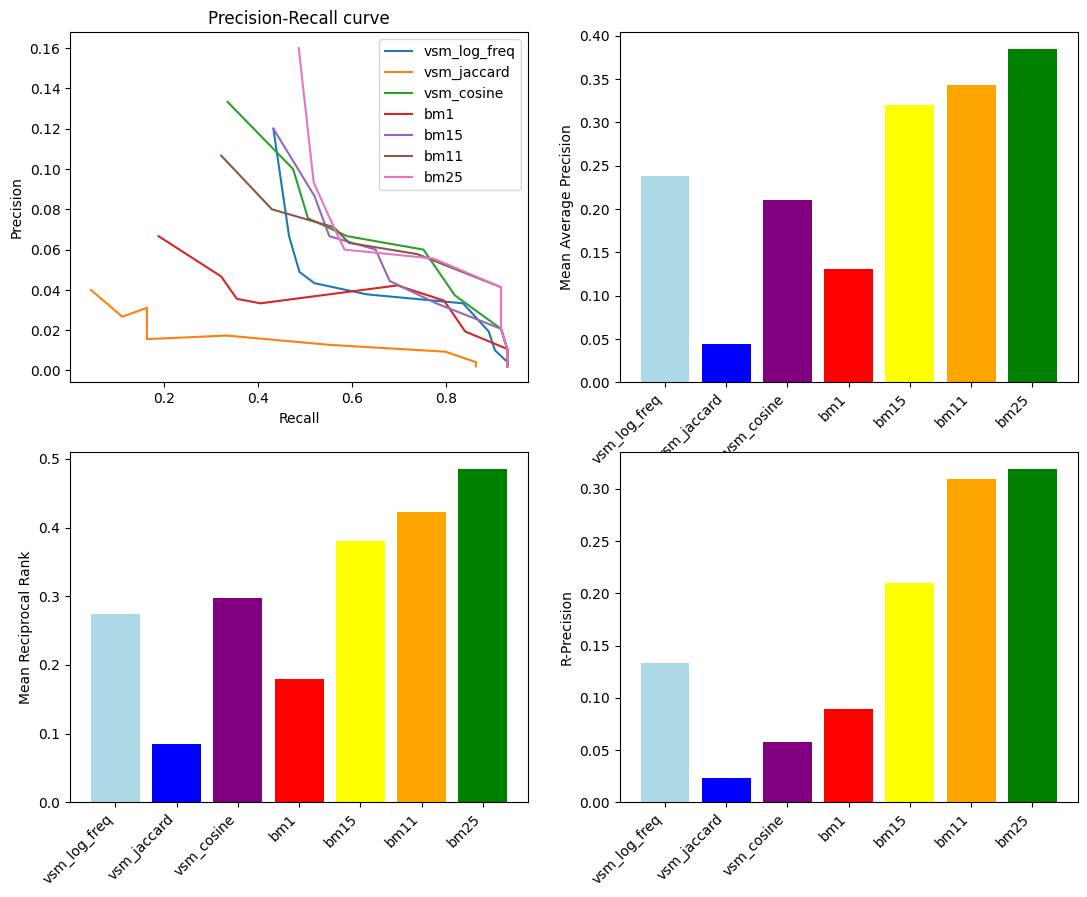

In [33]:
fig, axs = plt.subplots(2, 2, figsize=(13, 10))

# Precision-Recall curve
for model in results.keys():
    x_axis = [performance[model]['recall@5'], performance[model]['recall@10'], performance[model]['recall@15'],
              performance[model]['recall@20'], performance[model]['recall@30'], performance[model]['recall@50'], performance[model]['recall@100'],
              performance[model]['recall@200'], performance[model]['recall@500'], performance[model]['recall@1000']]
    y_axis = [performance[model]['p@5'], performance[model]['p@10'], performance[model]['p@15'],
              performance[model]['p@20'], performance[model]['p@30'], performance[model]['p@50'], performance[model]['p@100'],
              performance[model]['p@200'], performance[model]['p@500'], performance[model]['p@1000']]
    axs[0][0].plot(x_axis, y_axis, label=model)

# Add labels and title
axs[0][0].set_xlabel('Recall')
axs[0][0].set_ylabel('Precision')
axs[0][0].set_title('Precision-Recall curve')
axs[0][0].legend()

# Mean Average Precision
y_values = []
x_labels = []
for model in results.keys():
    y_values.append(performance[model]['map'])
    x_labels.append(model)
color = ['lightblue', 'blue', 'purple', 'red', 'yellow', 'orange', 'green']
axs[0][1].bar(x_labels, y_values, color=color)
axs[0][1].set_ylabel('Mean Average Precision')
axs[0][1].set_xticks(range(len(x_labels)))
axs[0][1].set_xticklabels(x_labels, rotation=45, ha='right')

# Mean Reciprocal Rank
y_values = []
x_labels = []
for model in results.keys():
    y_values.append(performance[model]['mrr'])
    x_labels.append(model)
color = ['lightblue', 'blue', 'purple', 'red', 'yellow', 'orange', 'green']
axs[1][0].bar(x_labels, y_values, color=color)
axs[1][0].set_ylabel('Mean Reciprocal Rank')
axs[1][0].set_xticks(range(len(x_labels)))
axs[1][0].set_xticklabels(x_labels, rotation=45, ha='right')


# R-Precision
y_values = []
x_labels = []
for model in results.keys():
    y_values.append(performance[model]['r_precision'])
    x_labels.append(model)
color = ['lightblue', 'blue', 'purple', 'red', 'yellow', 'orange', 'green']
axs[1][1].bar(x_labels, y_values, color=color)
axs[1][1].set_ylabel('R-Precision')
axs[1][1].set_xticks(range(len(x_labels)))
axs[1][1].set_xticklabels(x_labels, rotation=45, ha='right')




# Show the plot
plt.show()


### <span style="color:red"><b>TASK 10</b></span>

What are your main conclusions by looking at the obtained results?

- According to evaluation metrics like MAP, MRR, and R-Precision, the experimental findings show that BM25 consistently beats all other models. BM25'%s ability to incorporate term frequency saturation and document length normalization, which allows for more efficient ranking of relevant documents, is responsible for this better performance. Although BM11 and BM15 are competitive as well, they are not as flexible as BM25. On the other hand, Jaccard similarity performs the poorest due to its oversimplified handling of word overlap, whereas Vector Space Models perform moderately. Therefore, for the supplied dataset, BM25 turns out to be the most reliable and efficient retrieval model overall.


# Congratulations!


Congratulations on completing the assignment! Your dedication and effort are commendable. By successfully working through the coding exercises and written exercises, you have demonstrated a strong understanding of the concepts and principles related Information Retrieval.


Congratulations on finishing this notebook!




# Acknowledgement

## About the Author

This notebook was authored by Mohamed Reda Bouadjenek. He is a Senior Lecturer (Assistant Professor) of Applied Artificial Intelligence in the School of Information Technology at Deakin University, Australia.

## Contact Information

- **Email:** reda.bouadjenek@deakin.edu.au
- **GitHub:** https://github.com/rbouadjenek/

---
